# n1/n5 Alchemical Rule Overlap

This notebook compares alchemical rules by their composed QueryCGR identity, then displays rules that are unique to `n1` and `n5`. The last section cross-compares the two unique sets by the Morgan-like QueryCGR fingerprint from `test_diversity.ipynb` and returns the top-10 most similar rule pairs.


In [9]:
from __future__ import annotations

from collections import Counter, defaultdict
from functools import lru_cache
from hashlib import blake2b
from heapq import heappush, heapreplace
from math import log2
from pathlib import Path
from typing import Any, Iterable
import sys
import os

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-codex")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp/codex-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from matplotlib_venn import venn2

NOTEBOOK_CWD = Path.cwd()
if (NOTEBOOK_CWD / "route_analysis").exists():
    COMPOSITE_ROOT = NOTEBOOK_CWD
elif (NOTEBOOK_CWD.parent / "route_analysis").exists():
    COMPOSITE_ROOT = NOTEBOOK_CWD.parent
else:
    COMPOSITE_ROOT = Path("/Users/almazgil/Desktop/projects/Retro-BLEU/composite_rules")

if str(COMPOSITE_ROOT) not in sys.path:
    sys.path.insert(0, str(COMPOSITE_ROOT))

from route_analysis.alchemical_rules.alchemical import rule_cgr_key, rule_query_cgr


In [10]:
alchem_n1_path = COMPOSITE_ROOT / "res_alchem/n1/n1_alchemical_rules.tsv"
alchem_n5_path = COMPOSITE_ROOT / "res_alchem/n5/n5_alchemical_rules.tsv"

alchem_n1_df = pd.read_csv(alchem_n1_path, sep="	")
alchem_n5_df = pd.read_csv(alchem_n5_path, sep="	")

print("n1 rows:", len(alchem_n1_df), alchem_n1_path)
print("n5 rows:", len(alchem_n5_df), alchem_n5_path)


n1 rows: 8765 /Users/almazgil/Desktop/projects/Retro-BLEU/composite_rules/res_alchem/n1/n1_alchemical_rules.tsv
n5 rows: 10913 /Users/almazgil/Desktop/projects/Retro-BLEU/composite_rules/res_alchem/n5/n5_alchemical_rules.tsv


## QueryCGR Identity And Fingerprints

`QueryCGR_key` is used for exact set membership. The fingerprint functions below are copied from `test_diversity.ipynb` and are used only for approximate cross-similarity between rules that are unique to each set.


In [11]:
@lru_cache(maxsize=None)
def cached_rule_cgr_key(rule_smarts: str) -> str:
    return rule_cgr_key(rule_smarts)


def add_querycgr_keys(df: pd.DataFrame, dataset: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = df.copy()
    keys = []
    errors = []
    for row_index, rule_smarts in rows["Alchemical_rule"].items():
        try:
            keys.append(cached_rule_cgr_key(str(rule_smarts)))
        except Exception as exc:
            keys.append(None)
            errors.append(
                {
                    "dataset": dataset,
                    "row_index": row_index,
                    "error_type": type(exc).__name__,
                    "message": str(exc),
                    "Alchemical_rule": rule_smarts,
                }
            )
    rows["dataset"] = dataset
    rows["QueryCGR_key"] = keys
    return rows, pd.DataFrame(errors)


def stable_hash(obj: Any) -> int:
    text = repr(obj).encode("utf-8")
    return int.from_bytes(blake2b(text, digest_size=8).digest(), "big")


def query_atom_label(qcgr, atom_id: int, atom) -> tuple:
    return (
        repr(atom),
        tuple(getattr(qcgr, "_neighbors", {}).get(atom_id, ())),
        tuple(getattr(qcgr, "_p_neighbors", {}).get(atom_id, ())),
        tuple(getattr(qcgr, "_hybridizations", {}).get(atom_id, ())),
        tuple(getattr(qcgr, "_p_hybridizations", {}).get(atom_id, ())),
        getattr(qcgr, "_charges", {}).get(atom_id, None),
        getattr(qcgr, "_p_charges", {}).get(atom_id, None),
        getattr(qcgr, "_radicals", {}).get(atom_id, None),
        getattr(qcgr, "_p_radicals", {}).get(atom_id, None),
    )


def query_bond_label(bond) -> tuple:
    return (
        getattr(bond, "order", None),
        getattr(bond, "p_order", None),
        repr(bond),
    )


def query_cgr_morgan_bit_set(
    qcgr,
    min_radius: int = 1,
    max_radius: int = 4,
    length: int = 2048,
    number_active_bits: int = 2,
) -> set[int]:
    if length & (length - 1) != 0:
        raise ValueError("length should be a power of 2")

    mask = length - 1
    shift = int(log2(length))
    identifiers = {
        atom_id: stable_hash(query_atom_label(qcgr, atom_id, atom))
        for atom_id, atom in qcgr.atoms()
    }
    active_bits: set[int] = set()

    for radius in range(max_radius + 1):
        if radius >= min_radius:
            for value in identifiers.values():
                current = value
                for _ in range(number_active_bits):
                    active_bits.add(current & mask)
                    current >>= shift

        if radius == max_radius:
            break

        new_identifiers = {}
        for atom_id in identifiers:
            environment = tuple(
                sorted(
                    (
                        (stable_hash(query_bond_label(bond)), identifiers[neighbor_id])
                        for neighbor_id, bond in qcgr._bonds[atom_id].items()
                    ),
                    key=lambda item: (item[0], item[1]),
                )
            )
            new_identifiers[atom_id] = stable_hash((identifiers[atom_id], environment))
        identifiers = new_identifiers

    return active_bits


def tanimoto_bits(a: set[int], b: set[int]) -> float:
    union = a | b
    if not union:
        return 1.0
    return len(a & b) / len(union)


@lru_cache(maxsize=None)
def cached_rule_querycgr(rule_smarts: str):
    return rule_query_cgr(rule_smarts)


@lru_cache(maxsize=None)
def cached_rule_fp(
    rule_smarts: str,
    max_radius: int = 2,
    length: int = 4096,
    number_active_bits: int = 2,
) -> frozenset[int]:
    qcgr = cached_rule_querycgr(rule_smarts)
    return frozenset(
        query_cgr_morgan_bit_set(
            qcgr,
            max_radius=max_radius,
            length=length,
            number_active_bits=number_active_bits,
        )
    )


## Exact n1/n5 Overlap

These sets are exact QueryCGR identities, not raw SMARTS strings. A rule is `n1_only` if its composed QueryCGR identity is absent from the n5 table.


Unique n1 QueryCGRs: 8744
Unique n5 QueryCGRs: 10883
Overlap: 4623
Only n1: 4121
Only n5: 6260
QueryCGR key errors: 0


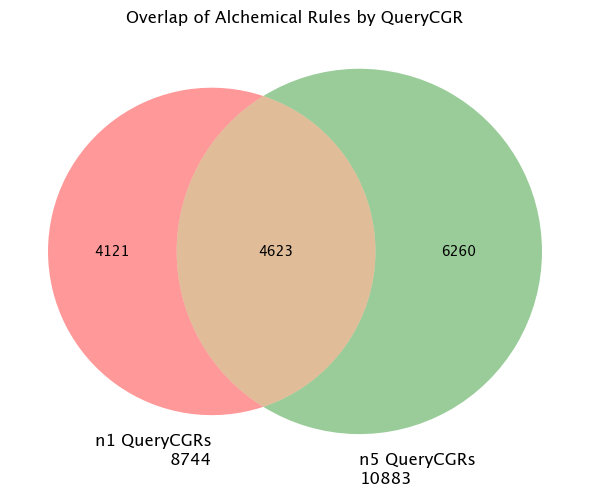

In [12]:
n1_rules_df, n1_key_errors = add_querycgr_keys(alchem_n1_df, "n1")
n5_rules_df, n5_key_errors = add_querycgr_keys(alchem_n5_df, "n5")
key_errors = pd.concat([n1_key_errors, n5_key_errors], ignore_index=True)

n1_set = set(n1_rules_df["QueryCGR_key"].dropna())
n5_set = set(n5_rules_df["QueryCGR_key"].dropna())

overlap_keys = n1_set & n5_set
only_n1_keys = n1_set - n5_set
only_n5_keys = n5_set - n1_set

print("Unique n1 QueryCGRs:", len(n1_set))
print("Unique n5 QueryCGRs:", len(n5_set))
print("Overlap:", len(overlap_keys))
print("Only n1:", len(only_n1_keys))
print("Only n5:", len(only_n5_keys))
print("QueryCGR key errors:", len(key_errors))

plt.figure(figsize=(6, 6))
venn2(
    subsets=(len(only_n1_keys), len(only_n5_keys), len(overlap_keys)),
    set_labels=(f"n1 QueryCGRs\n{len(n1_set)}", f"n5 QueryCGRs\n{len(n5_set)}"),
)
plt.title("Overlap of Alchemical Rules by QueryCGR")
plt.tight_layout()
plt.show()

if not key_errors.empty:
    display(key_errors.head(20))


## Display Unique Rules

The full unique tables are `unique_n1_df` and `unique_n5_df`. The display below is sorted by `popularity` so the most common unique rules are easiest to inspect first.


In [ ]:
def display_unique_rules(rules_df: pd.DataFrame, unique_keys: set[str], title: str, n: int = 25) -> pd.DataFrame:
    unique_df = (
        rules_df[rules_df["QueryCGR_key"].isin(unique_keys)]
        .sort_values(["popularity", "route_ids_size"], ascending=False)
        .reset_index(names="source_row")
    )
    cols = [
        "source_row",
        "popularity",
        "route_ids_size",
        "output_reactants_num",
        "Reference",
        "Alchemical_rule",
        "QueryCGR_key",
    ]
    cols = [col for col in cols if col in unique_df.columns]
    display(Markdown(f"### {title}: {len(unique_df)} rows / {len(unique_keys)} unique QueryCGRs"))
    display(unique_df[cols].head(n))
    return unique_df

# pd.set_option("display.max_colwidth", 160)
unique_n1_df = display_unique_rules(n1_rules_df, only_n1_keys, "n1-only alchemical rules")
unique_n5_df = display_unique_rules(n5_rules_df, only_n5_keys, "n5-only alchemical rules")

unique_n1_rule_set = set(unique_n1_df["Alchemical_rule"])
unique_n5_rule_set = set(unique_n5_df["Alchemical_rule"])


### n1-only alchemical rules: 4123 rows / 4121 unique QueryCGRs

,source_row,popularity,route_ids_size,output_reactants_num,Reference,Alchemical_rule,QueryCGR_key
0,6,40,40,3,"6,62,90,188,438,957,1168,1257,1558,1571,1587,1705,1706,1936,1941,2142,2398,2554,2839,3268,3687,3775,4154,5927,6682,6823,6871,6947,7181,7262,7478,7775,8059,8...",[C;D2:1]-[n;D3:2]:1:[c;D3:3](=[O;D1:4]):[n;D3:5](-[C;D2:6]):[c;D3:12](=[O;D1:13]):[c;D3:14](:[c;D2:15]):[c;D3:17]:1:[c;D2:16].[c;D3:7]-[C;D3:8](=[O;D1:9])-[...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
1,7,40,40,2,"6,62,90,188,438,957,1168,1257,1558,1571,1587,1705,1706,1936,1941,2142,2398,2554,2839,3268,3687,3775,4154,5927,6682,6823,6871,6947,7181,7262,7478,7775,8059,8...",[N;D2:1]=[c;D3:2]:1:[c;D2:3]:[c;D3:4](-[c;D3:5]):[o;D2:6]:[c;D3:7](:[c;D2:8]):[c;D3:15]:1:[c;D2:14]:[c;D3:9]-[C;D3:10](=[O;D1:11])-[N;D2:12]-[C;D2:13]>>[N;D...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
2,17,29,29,2,"66,271,737,1193,1197,1340,1468,1921,2611,2665,2976,2990,3301,3484,3515,3859,4085,4309,4529,4777,4817,5159,5274,6716,7577,8097,8427,8556,8720",[c;D3:1]-[N;D2:2]-[S;D4:3](=[O;D1:4])(=[O;D1:5])-[c;D3:6]>>[S;D4:3](=[O;D1:5])(-[c;D3:6])(=[O;D1:8])-[Cl;D1:9].[c;D3:1]-[N;D3+:2](-[O;D1-:4])=[O;D1:7],"[[[6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(4,)"", ""(4,)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(4,)"", ""(4,)"", ""None""], [7, ""0"",..."
3,26,26,26,2,"213,578,665,1009,1322,1764,2067,2291,2307,2577,2705,2923,3186,4358,5048,5484,5959,6010,6495,6737,8300,8346,9216,9276,9346,9774",[c;D3:1]-[N;D2:2]-[C;D3:3](=[O;D1:4])-[O;D2:5]>>[c;D3:1]-[N;D3+:2](-[O;D1-:4])=[O;D1:6].[C;D3:3](-[O;D2:5])(=[O;D1:7])-[Cl;D1:8],"[[[6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(4,)"", ""(4,)"", ""None""]..."
4,29,25,25,2,"2,158,523,535,852,932,1384,2471,3144,3203,3258,3437,3449,3508,3685,4803,5077,5675,5750,5806,5815,7039,7148,8794,8854",[c;D3:1](-[n;D3:2]:1:[c;D3:3](=[O;D1:4]):[c;D2:5]:[c;D3:6](-[C;D4:7]):[n;D3:8](-[C;D1:9]):[c;D3:10]:1=[O;D1:11]):[c;D3:12]-[N;D2:13]-[C;D3:14](=[O;D1:15])-[...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(4,)"", ""(1, 2, 3)"", ""N..."
5,33,24,24,3,"120,146,404,663,689,2021,2443,2463,2752,2878,3289,3684,4670,5568,6056,6486,6855,6929,7323,7566,7654,7665,8489,9273",[C;D2:1]-[n;D3:2]:1:[c;D3:3](=[O;D1:4]):[n;D3:5](-[C;D2:6]):[c;D3:13](:[c;D2:14]):[c;D3:16]:1:[c;D2:15].[c;D3:7]-[N;D2:8]-[S;D4:9](-[C;D1:10])(=[O;D1:11])=[...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
6,34,24,24,2,"120,146,404,663,689,2021,2443,2463,2752,2878,3289,3684,4670,5568,6056,6486,6855,6929,7323,7566,7654,7665,8489,9273",[C;D3:1]-[c;D3:2]:1:[c;D2:3]:[n;D2:4]:[c;D3:5]:2:[c;D3:6](:[c;D2:7]:[c;D3:8]-[N;D2:9]-[S;D4:10](-[C;D1:11])(=[O;D1:12])=[O;D1:13]):[c;D3:15](:[c;D2:14]):[c;...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
7,37,24,24,3,"66,271,737,1340,1468,1921,2611,2976,2990,3301,3484,3515,3859,4085,4309,4529,4777,4817,5274,6716,7577,8097,8556,8720",[c;D3:1]-[N;D2:2]-[S;D4:3](=[O;D1:4])(=[O;D1:5])-[c;D3:6].[c;D3:7]-[c;D3:8]:1:[n;D2:9]:[n;D3:10](:[c;D3:11]):[c;D3:13](:[c;D3:12]):[c;D3:14](=[O;D1:15]):[n;...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(4,)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", "

### n5-only alchemical rules: 6267 rows / 6260 unique QueryCGRs

,source_row,popularity,route_ids_size,output_reactants_num,Reference,Alchemical_rule,QueryCGR_key
0,25,33,33,3,"112,546,1216,1387,1497,1601,2263,2698,2703,2757,3072,3446,4070,4095,4185,4577,5838,5860,6025,6182,6508,6830,7266,7437,7789,8505,8635,8766,8820,8861,8944,901...",[C;D1:1]-[S;D4:2](=[O;D1:3])(=[O;D1:4])-[N;D2:5]-[c;D3:6].[c;D3:7]-[n;D3:8]:1:[c;D3:9](=[O;D1:10]):[c;D2:11]:[c;D3:12](-[C;D4:13]):[n;D3:14](:[c;D2:15]):[c;...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(4,)"", ""(1, 2, 3)"", ""N..."
1,27,33,33,3,"112,546,1216,1387,1497,1601,2263,2698,2703,2757,3072,3446,4070,4095,4185,4577,5838,5860,6025,6182,6508,6830,7266,7437,7789,8505,8635,8766,8820,8861,8944,901...",[c;D3:1]-[N;D2:2]-[S;D4:3](-[C;D1:4])(=[O;D1:5])=[O;D1:6].[c;D3:7]-[c;D3:8]:1:[c;D2:9]:[n;D3:10](-[C;D1:11]):[c;D3:12](=[O;D1:13]):[c;D2:14]:[c;D2:15]:1>>[S...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
2,30,31,31,2,"1,101,171,194,197,198,540,699,1284,2118,2365,2377,2509,2576,2652,2718,2939,2984,3150,3342,3607,4013,4872,5119,5467,7220,7485,7789,8975,8992,9174",[C;D2:1]-[c;D3:2]:1:[c;D3:3](-[C;D2:4]):[c;D3:5](=[O;D1:6]):[o;D2:7]:[c;D3:8]:2:[c;D3:9]:1:[c;D2:10]:[c;D3:11](:[c;D3:12]:[c;D2:13]:2)-[N;D1:14]>>[C;D2:1]-[...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
3,31,31,31,2,"1,101,171,194,197,198,540,699,1284,2118,2365,2377,2509,2576,2652,2718,2939,2984,3150,3342,3607,4013,4872,5119,5467,7220,7485,7789,8975,8992,9174",[N;D1:1]-[c;D3:2](:[c;D2:3]:[c;D3:4]-[c;D3:5]:1:[n;D2:6]:[c;D2:7]:[c;D3:8](-[C;D4:9]):[n;D3:10](-[C;D1:11]):[c;D3:12]:1=[O;D1:13]):[c;D3:14]>>[c;D2:2](:[c;D...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(4,)"", ""(1, 2, 3)"", ""N..."
4,36,29,29,2,"93,266,563,1345,1662,1813,1983,2076,2144,2219,2459,3534,3601,3717,3973,4502,4507,4517,4603,4738,5183,5276,6305,6434,6530,7870,8588,9165,9701",[C;D1:1]-[c;D3:2]:1:[c;D2:3]:[c;D3:4](=[O;D1:5]):[c;D3:6](-[C;D2:7]-[N;D2:8]-[C;D3:9](=[O;D1:10])-[c;D3:11]):[c;D3:12](-[C;D1:13]):[n;D2:14]:1>>[C;D3:9](=[O...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
5,37,29,29,2,"93,266,563,1345,1662,1813,1983,2076,2144,2219,2459,3534,3601,3717,3973,4502,4507,4517,4603,4738,5183,5276,6305,6434,6530,7870,8588,9165,9701",[C;D2:1]-[n;D3:2]:1:[c;D3:3](=[O;D1:4]):[c;D3:5](:[c;D2:6]:[c;D3:7]-[C;D3:8](=[O;D1:9])-[N;D2:10]-[C;D2:11]):[c;D3:13](:[c;D2:12]):[n;D3:14](-[C;D2:15]):[c;...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(1,)"", ""(1,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(2,)"", ""(2,)"", ""(1, 2, 3)"", ""(1, 2, 3)..."
6,38,29,29,3,"596,931,957,1077,1172,1238,1894,1955,2494,2602,2606,2924,2970,3463,3581,3797,4110,4377,4409,4559,5289,5471,5733,6101,7194,7267,7952,8019,9630",[N;D1:1]-[c;D3:2].[c;D3:3]-[N;D2:4]-[C;D3:5](=[O;D1:6])-[O;D2:7]>>[N;D3+:1](-[c;D3:2])(=[O;D1:8])-[O;D1-:9].[c;D3:3]-[N;D1:4].[C;D3:5](=[O;D1:6])(-[O;D2:7])...,"[[[6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(1, 2, 3)"", ""(1, 2, 3)"", ""None""], [6, ""0"", ""0"", ""False"", ""False"", ""(3,)"", ""(3,)"", ""(4,)"", ""(4,)"", ""None""]..."
7,41,29,29,2,"93,266,563,1345,1662,1813,1983,2076,2144,2219,2459,3534,3601,3717,3973,4502,4507,4517,4603,4738,5183,5276,6305,6434,6530,7870,8588,9165,9701",[c;D3:1]-[C;D3:2](=[O;D1:3])-[N;D2:4]-[C;D2:5]-[c;D3:6]:1:[c;D3:7](-[C;D1:8]):[c;D2:9]:[c;D3:10](-[C;D1:11]):[n;D2:

## Optional Visual Check Of A Few QueryCGRs

Use this small visual sample to confirm that the displayed SMARTS really correspond to different alchemical transformations.


In [14]:
def display_rule_querycgr_sample(unique_df: pd.DataFrame, title: str, n: int = 3) -> None:
    display(Markdown(f"### {title}"))
    for _, row in unique_df.head(n).iterrows():
        display(Markdown(f"`popularity={row.get('popularity', '')}`  \n`{row['Alchemical_rule']}`"))
        display(cached_rule_querycgr(row["Alchemical_rule"]))

# Uncomment if you want depictions inside the notebook output.
display_rule_querycgr_sample(unique_n1_df, "n1-only examples", n=3)
display_rule_querycgr_sample(unique_n5_df, "n5-only examples", n=3)


### n1-only examples

`popularity=40`  
`[C;D2:1]-[n;D3:2]:1:[c;D3:3](=[O;D1:4]):[n;D3:5](-[C;D2:6]):[c;D3:12](=[O;D1:13]):[c;D3:14](:[c;D2:15]):[c;D3:17]:1:[c;D2:16].[c;D3:7]-[C;D3:8](=[O;D1:9])-[N;D2:10]-[C;D2:11]>>[N;D1:10]-[C;D2:11].[C;D2:1]-[N;D3:2]-1-[C;D3:3](=[O;D1:4])-[N;D3:5](-[C;D2:6])-[C;D3:12](=[O;D1:13])-[c;D3:14](:[c;D2:15]):[c;D3:17]-1:[c;D2:16].[c;D3:7]-[C;D3:8](=[O;D1:9])-[O;D2:18]-[C;D1:19]`

`popularity=40`  
`[N;D2:1]=[c;D3:2]:1:[c;D2:3]:[c;D3:4](-[c;D3:5]):[o;D2:6]:[c;D3:7](:[c;D2:8]):[c;D3:15]:1:[c;D2:14]:[c;D3:9]-[C;D3:10](=[O;D1:11])-[N;D2:12]-[C;D2:13]>>[N;D1:12]-[C;D2:13].[N;D2:1]=[C;D3:2]-1-[C;D2:3]=[C;D3:4](-[c;D3:5])-[O;D2:6]-[c;D3:7](:[c;D2:8]):[c;D3:15]-1:[c;D2:14]:[c;D3:9]-[C;D3:10](=[O;D1:11])-[O;D2:16]-[C;D1:17]`

`popularity=29`  
`[c;D3:1]-[N;D2:2]-[S;D4:3](=[O;D1:4])(=[O;D1:5])-[c;D3:6]>>[S;D4:3](=[O;D1:5])(-[c;D3:6])(=[O;D1:8])-[Cl;D1:9].[c;D3:1]-[N;D3+:2](-[O;D1-:4])=[O;D1:7]`

### n5-only examples

`popularity=33`  
`[C;D1:1]-[S;D4:2](=[O;D1:3])(=[O;D1:4])-[N;D2:5]-[c;D3:6].[c;D3:7]-[n;D3:8]:1:[c;D3:9](=[O;D1:10]):[c;D2:11]:[c;D3:12](-[C;D4:13]):[n;D3:14](:[c;D2:15]):[c;D3:17]:1:[n;D2:16]>>[N;D3+:5](-[c;D3:6])(=[O;D1:19])-[O;D1-:20].[c;D3:7]-[N;D3:8]-1-[C;D3:9](=[O;D1:10])-[C;D2:11]=[C;D3:12](-[C;D4:13])-[n;D3:14](:[c;D2:15]):[c;D3:17]-1:[n;D2:16].[C;D1:1]-[S;D4:2](=[O;D1:3])(=[O;D1:4])-[Cl;D1:18]`

`popularity=33`  
`[c;D3:1]-[N;D2:2]-[S;D4:3](-[C;D1:4])(=[O;D1:5])=[O;D1:6].[c;D3:7]-[c;D3:8]:1:[c;D2:9]:[n;D3:10](-[C;D1:11]):[c;D3:12](=[O;D1:13]):[c;D2:14]:[c;D2:15]:1>>[S;D4:3](-[C;D1:4])(=[O;D1:5])(=[O;D1:6])-[Cl;D1:18].[c;D3:1]-[N;D3+:2](=[O;D1:16])-[O;D1-:17].[c;D3:7]-[C;D3:8]-1=[C;D2:9]-[N;D3:10](-[C;D1:11])-[C;D3:12](=[O;D1:13])-[C;D2:14]=[C;D2:15]-1`

`popularity=31`  
`[C;D2:1]-[c;D3:2]:1:[c;D3:3](-[C;D2:4]):[c;D3:5](=[O;D1:6]):[o;D2:7]:[c;D3:8]:2:[c;D3:9]:1:[c;D2:10]:[c;D3:11](:[c;D3:12]:[c;D2:13]:2)-[N;D1:14]>>[C;D2:1]-[C;D3:2]-1=[C;D3:3](-[C;D2:4])-[C;D3:5](=[O;D1:6])-[O;D2:7]-[c;D3:8]:2:[c;D3:9]-1:[c;D2:10]:[c;D2:11]:[c;D3:12]:[c;D2:13]:2.[N;D3+:14](=[O;D1:15])(-[O;D1-:16])-[O;D1:17]`

## Top-10 Similar Unique Rules Across n1 And n5

`top_cross_similar_rules(left_rules, right_rules)` accepts any two iterables of rule SMARTS. It composes QueryCGRs, creates Morgan-like bit-set fingerprints, and performs an exact top-k cross-comparison. The inverted-bit index avoids materializing the full `len(left) x len(right)` similarity matrix.


In [15]:
def top_cross_similar_rules(
    left_rules: Iterable[str],
    right_rules: Iterable[str],
    *,
    left_name: str = "n1_only",
    right_name: str = "n5_only",
    top_n: int = 10,
    max_radius: int = 2,
    length: int = 4096,
    number_active_bits: int = 2,
    progress_every: int = 500,
) -> pd.DataFrame:
    left_rules = sorted(set(map(str, left_rules)))
    right_rules = sorted(set(map(str, right_rules)))

    right_fps: list[frozenset[int]] = []
    right_by_bit: dict[int, list[int]] = defaultdict(list)
    right_errors = []
    for right_index, rule in enumerate(right_rules):
        try:
            fp = cached_rule_fp(rule, max_radius, length, number_active_bits)
        except Exception as exc:
            right_errors.append({"side": right_name, "index": right_index, "rule": rule, "error": repr(exc)})
            fp = frozenset()
        right_fps.append(fp)
        for bit in fp:
            right_by_bit[bit].append(right_index)

    heap: list[tuple[float, int, int, int]] = []
    left_errors = []
    compared_candidate_pairs = 0

    for left_index, rule in enumerate(left_rules):
        if progress_every and left_index and left_index % progress_every == 0:
            print(f"processed {left_index}/{len(left_rules)} {left_name} rules; candidate pairs={compared_candidate_pairs}")
        try:
            left_fp = cached_rule_fp(rule, max_radius, length, number_active_bits)
        except Exception as exc:
            left_errors.append({"side": left_name, "index": left_index, "rule": rule, "error": repr(exc)})
            continue

        shared_counts: Counter[int] = Counter()
        for bit in left_fp:
            shared_counts.update(right_by_bit.get(bit, ()))

        compared_candidate_pairs += len(shared_counts)
        for right_index, shared_bits in shared_counts.items():
            right_fp = right_fps[right_index]
            denom = len(left_fp) + len(right_fp) - shared_bits
            similarity = shared_bits / denom if denom else 1.0
            item = (similarity, shared_bits, left_index, right_index)
            if len(heap) < top_n:
                heappush(heap, item)
            elif item > heap[0]:
                heapreplace(heap, item)

    rows = []
    for similarity, shared_bits, left_index, right_index in sorted(heap, reverse=True):
        left_rule = left_rules[left_index]
        right_rule = right_rules[right_index]
        rows.append(
            {
                f"{left_name}_index": left_index,
                f"{right_name}_index": right_index,
                "similarity": similarity,
                "shared_bits": shared_bits,
                f"{left_name}_bits": len(cached_rule_fp(left_rule, max_radius, length, number_active_bits)),
                f"{right_name}_bits": len(cached_rule_fp(right_rule, max_radius, length, number_active_bits)),
                f"{left_name}_rule": left_rule,
                f"{right_name}_rule": right_rule,
            }
        )

    result = pd.DataFrame(rows)
    result.attrs["left_errors"] = left_errors
    result.attrs["right_errors"] = right_errors
    result.attrs["compared_candidate_pairs"] = compared_candidate_pairs
    return result


In [16]:
top10_unique_cross = top_cross_similar_rules(
    unique_n1_rule_set,
    unique_n5_rule_set,
    left_name="n1_only",
    right_name="n5_only",
    top_n=10,
    max_radius=2,
    length=4096,
    number_active_bits=2,
    progress_every=500,
)

print("candidate pairs compared:", top10_unique_cross.attrs["compared_candidate_pairs"])
print("left parse/fingerprint errors:", len(top10_unique_cross.attrs["left_errors"]))
print("right parse/fingerprint errors:", len(top10_unique_cross.attrs["right_errors"]))
display(top10_unique_cross)


processed 500/4123 n1_only rules; candidate pairs=1699766
processed 1000/4123 n1_only rules; candidate pairs=3391528
processed 1500/4123 n1_only rules; candidate pairs=5196258
processed 2000/4123 n1_only rules; candidate pairs=6915080
processed 2500/4123 n1_only rules; candidate pairs=8685194
processed 3000/4123 n1_only rules; candidate pairs=10562794
processed 3500/4123 n1_only rules; candidate pairs=12240762
processed 4000/4123 n1_only rules; candidate pairs=14065108
candidate pairs compared: 14473617
left parse/fingerprint errors: 0
right parse/fingerprint errors: 0


,n1_only_index,n5_only_index,similarity,shared_bits,n1_only_bits,n5_only_bits,n1_only_rule,n5_only_rule
0,3721,5335,0.825000,66,76,70,[c;D3:1]:[c;D3:10]:1:[n;D3:3](:[n;D2:2]):[c;D3:4](=[O;D1:5]):[c;D2:6]:[c;D3:7](-[c;D3:8]):[n;D2:9]:1>>[C;D3:4](=[O;D1:5])(-[C;D2:6]-[C;D3:15](=[O;D1:16])-[O...,[c;D3:1]-[c;D3:2]:1:[c;D2:3]:[c;D3:4](=[O;D1:5]):[n;D3:6](:[n;D2:7]):[c;D3:9](:[c;D3:8]):[n;D2:10]:1>>[C;D2:3](-[C;D3:4](=[O;D1:5])-[O;D2:11]-[C;D2:12]-[C:1...
1,3937,5838,0.776471,66,80,71,[c;D3:1]:[c;D3:4]:1:[c;D3:3](:[c;D2:2]):[n;D3:9](:[c;D3:7](:[c;D2:6]:[c;D2:5]:1)=[O;D1:8])-[C;D2:10]-[C;D2:11]-[N;D3:12](-[C;D2:13])-[C;D2:15]-[C;D2:14]>>[c...,[c;D3:1]:[c;D3:2]:1:[c;D2:3]:[c;D2:4]:[c;D3:5](=[O;D1:6]):[n;D3:7](-[C;D2:8]-[C;D2:9]-[N;D3:10](-[C;D2:11])-[C;D2:12]):[c;D3:13]:1:[c;D2:14]>>[N;D3:10](-[C;...
2,2774,3906,0.771429,54,62,62,[c;D2:1]:[c;D3:2](-[N;D1:3]):[c;D2:4]>>[c;D2:1]:[c;D3:2](:[c;D2:4])-[C;D3:5](=[O;D1:6])-[O;D2:7]-[C:8]-[C:9].[N;D2:3](=[N;D2+:10]=[N;D1-:11])-[P;D4:12](-[c;...,[c;D2:1]:[c;D3:2](-[N;D1:3]):[c;D2:4]>>[c;D2:1]:[c;D3:2](:[c;D2:4])-[C;D3:5](=[O;D1:10])-[O;D2:11]-[C:12](-[C:13])(-[C:14])-[C:15].[N;D2:3](=[N;D2+:6]=[N;D1...
3,2774,3908,0.764706,52,62,58,[c;D2:1]:[c;D3:2](-[N;D1:3]):[c;D2:4]>>[c;D2:1]:[c;D3:2](:[c;D2:4])-[C;D3:5](=[O;D1:6])-[O;D2:7]-[C:8]-[C:9].[N;D2:3](=[N;D2+:10]=[N;D1-:11])-[P;D4:12](-[c;...,[c;D2:1]:[c;D3:2](-[N;D1:3]):[c;D2:4]>>[c;D2:1]:[c;D3:2](:[c;D2:4])-[C;D3:5](=[O;D1:7])-[O;D2:8]-[C:9].[N;D2:3](=[N;D2+:6]=[N;D1-:10])-[P;D4:11](=[O;D1:12])...
4,682,1025,0.760417,73,85,84,[C;D2:1]-[C;D2:2]-[N;D3:3](-[C;D3:4](-[C;D1:5])=[O;D1:6])-[c;D3:7].[c;D3:8]-[c;D3:9]:1:[c;D2:10]:[c;D3:11](=[O;D1:12]):[c;D3:13](:[c;D3:14]):[c;D3:16](:[c;D...,[C;D2:1]-[C;D2:2]-[N;D3:3](-[c;D3:4])-[C;D3:16](-[C;D1:15])=[O;D1:17].[c;D3:5]-[c;D3:6]:1:[c;D2:7]:[c;D3:8](=[O;D1:9]):[c;D3:10](:[c;D3:11](:[o;D2:12]:1):[c...
5,252,2525,0.759494,60,70,69,[C;D1:1]-[N;D2:2]-[C;D3:3](=[O;D1:4])-[c;D3:5]:[c;D3:6]-[N;D2:7]-[C;D3:8](=[O;D1:9])-[c;D3:10]:1:[c;D2:11]:[c;D3:12]:[n;D2:13]:[n;D3:14]:1-[c;D3:15]>>[C;D3:...,[C;D3:1]-[N;D2:2]-[C;D3:3](=[O;D1:4])-[c;D3:5]:[c;D3:6]-[N;D2:7]-[C;D3:8](=[O;D1:9])-[c;D3:10]:1:[c;D2:11]:[c;D3:12]:[n;D2:13]:[n;D3:14]:1-[c;D3:15]>>[C;D3:...
6,3839,4225,0.757576,75,87,87,[c;D3:1]:[c;D3:2]:1:[s;D2:3]:[c;D3:4](-[c;D3:5]):[n;D2:6]:[c;D3:7]:1:[c;D2:8]>>[C;D3:4](-[c;D3:5])(=[O;D1:9])-[Cl;D1:10].[c;D3:1]:[c;D2:2]:[c;D3:7](-[N;D1:6...,[c;D2:1]:[c;D3:2]:1:[c;D3:3](:[c;D2:4]):[n;D2:5]:[c;D3:6](-[c;D3:7]):[s;D2:8]:1>>[C;D3:6](-[c;D3:7])(=[O;D1:9])-[Cl;D1:10].[S;D1:8]=[P;D4:11]-1(-[S;D2:12]-[...
7,1278,3708,0.750000,72,84,84,[C;D2:1]-[n;D3:2]:1:[c;D3:3](-[C;D2:4]):[c;D3:5](-[c;D3:6]):[c;D3:7](:[c;D2:8]:[c;D3:9]-[O;D2:10]-[C;D2:11]-[C;D3:12]):[c;D3:14](:[c;D2:13]):[c;D3:15]:1=[O;...,[O;D2:1]-[c;D3:2]:1:[c;D3:3](-[C;D2:4]):[n;D3:5](-[C;D2:6]):[c;D3:7](=[O;D1:8]):[c;D3:9](:[c;D2:10]):[c;D3:16]:1:[c;D2:15]:[c;D3:11]-[O;D2:12]-[C;D2:13]-[C;...
8,2853,2689,0.750000,60,64,76,[c;D2:1]:[c;D3:2](-[O;D2:3]-[C;D2:4]-[c;D3:5]:1:[c;D3:6](-[C;D2:7]):[n;D2:8]:[o;D2:9]:[c;D3:10]:1-[C;D3:11]):[c;D2:12]>>[O;D2:3](-[C;D3:4](-[C;D2:5]-[C;D3:1...,[C;D3:1]-[c;D3:2]:1:[c;D3:3](-[C;D2:4]-[O;D2:5]-[c;D3:6](:[c;D2:7]):[c;D2:10]):[c;D3:11](-[C;D2:12]):[n;D2:13]:[o;D2:14]:1.[C;D3:8]-[O;D2:9]-[C;D1:15]>>[C;D...
9,2854,2690,0.736842,56,60,72,[c;D2:1]:[c;D3:2](-[O;D2:3]-[C;D2:4]-[c;D3:5]:1:[c;D3:6](-[C;D2:7]):[n;D2:8]:[o;D2:9]:[c;D3:10]:1-[C;D3:11]):[c;D2:12]>>[O;D2:3](-[C;D3:4](-[C;D2:5]-[C;D3:1...,[C;D3:1]-[c;D3:2]:1:[c;D3:3](-[C;D2:4]-[O;D2:5]-[c;D3:6](:[c;D2:7]):[c;D2:10]):[c;D3:11](-[C;D2:12]):[n;D2:13]:[o;D2:14]:1.[C;D3:8]-[O;D2:9]-[C;D1:15]>>[C;D...


In [22]:
smarts(top10_unique_cross.iloc[0]['n1_only_rule'])

In [23]:
smarts(top10_unique_cross.iloc[0]['n5_only_rule'])

## Inspect One Similar Pair

Change `pair_id` to display any pair from `top10_unique_cross`.


In [ ]:
pair_id = 0
if not top10_unique_cross.empty:
    pair = top10_unique_cross.iloc[pair_id]
    display(Markdown(f"### n1-only rule, similarity={pair['similarity']:.3f}"))
    display(Markdown(f"`{pair['n1_only_rule']}`"))
    display(cached_rule_querycgr(pair["n1_only_rule"]))

    display(Markdown("### n5-only rule"))
    display(Markdown(f"`{pair['n5_only_rule']}`"))
    display(cached_rule_querycgr(pair["n5_only_rule"]))
